# 07 · Explainability: what drives the predictions?

**Goal.** Show which information the model relies on, in which direction, and how far those explanations can be trusted.

**Method: SHAP** (SHapley Additive exPlanations). For one person, the model's output is split into a contribution from each feature, so that the contributions add up to the prediction. Positive means "pushed the risk up", negative means "pushed it down". Averaging the size of the contributions over many people gives a global importance.

**Three things SHAP does not tell you.** They must be said in the report and in the viva:

1. **It explains the model, not the disease.** "CDR-SB has the largest SHAP value" means the model leans on CDR-SB. It does not mean CDR-SB causes dementia.
2. **Correlated features share credit unpredictably.** Memory, language and the global screen measure overlapping things. How SHAP divides credit among them can change from one training run to the next. That is why this notebook reports **groups** first and individual features second, and measures stability.
3. **Units.** Values are in log-odds. Only their relative size and sign are interpreted here.

The numbers come from `scripts/explain.py` (XGBoost, first-visit cohort, 3-year dementia target, test participants). Plots with one dot per participant are deliberately not used, because of the data use agreement; every figure is an average over a group.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu, modeling as M

nu.set_style()
r = json.loads((nu.REPORTS / "phase7_shap_results.json").read_text())
GROUP_OF = {f: g for g, feats in M.FEATURE_GROUPS.items() for f in feats}
GROUP_COLOR = dict(zip(M.FEATURE_GROUPS, [nu.AQUA, nu.VIOLET, nu.RED, nu.BLUE, nu.ORANGE]))
LABEL = {"CDRSUM": "CDR-SB at index", "is_mci": "MCI at index", "z_memory": "Memory z-score", "age": "Age", "z_executive": "Executive / speed z-score",
         "z_global": "Global screen z-score (MMSE / MoCA)", "z_language": "Language z-score", "npi_count": "Number of behavioural symptoms (NPI-Q)",
         "apoe_e4_count": "APOE e4 count", "race_white": "Race: White", "educ_years": "Years of education", "gds": "Depression scale (GDS)", "bmi": "BMI",
         "z_attention": "Attention z-score", "z_visuospatial": "Visuospatial z-score", "bp_sys": "Systolic BP", "pulse_pressure": "Pulse pressure",
         "med_count": "Number of medications", "heart_rate": "Heart rate", "is_impaired_not_mci": "Impaired, not MCI at index", "hispanic": "Hispanic"}
print(f"Explained on {r['n_test']:,} test participants")

Explained on 2,286 test participants


## 1. Which categories matter?

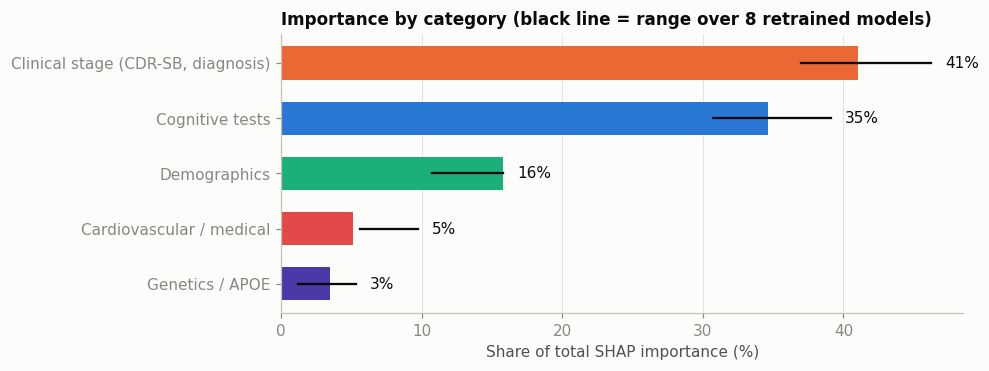

,Share %,Lowest over refits %,Highest over refits %,Number of features
"Clinical stage (CDR-SB, diagnosis)",41.0,37.0,46.2,3
Cognitive tests,34.6,30.8,39.1,9
Demographics,15.8,10.7,15.8,8
Cardiovascular / medical,5.1,5.6,9.7,25
Genetics / APOE,3.5,1.2,5.3,3


In [2]:
gi = pd.Series(r["group_importance"]); share = gi / gi.sum() * 100
rng = pd.DataFrame(r["stability"]["group_share_range"]).T.reindex(gi.index) * 100
fig, ax = plt.subplots(figsize=(8, 3.3))
ypos = np.arange(len(gi))[::-1]
ax.barh(ypos, share.values, color=[GROUP_COLOR[g] for g in gi.index], height=0.6)
for yv, g in zip(ypos, gi.index):
    ax.plot([rng.loc[g, "min"], rng.loc[g, "max"]], [yv, yv], color=nu.INK, lw=1.5)
    ax.text(max(share[g], rng.loc[g, "max"]) + 1, yv, f"{share[g]:.0f}%", va="center")
ax.set_yticks(ypos, gi.index); ax.set_xlabel("Share of total SHAP importance (%)"); ax.grid(axis="y", visible=False)
ax.set_title("Importance by category (black line = range over 8 retrained models)")
nu.savefig(fig, "07_shap_groups"); plt.show()
pd.DataFrame({"Share %": share.round(1), "Lowest over refits %": rng["min"].round(1), "Highest over refits %": rng["max"].round(1),
              "Number of features": pd.Series({g: len(f) for g, f in M.FEATURE_GROUPS.items()})}).loc[gi.index]

* About three quarters of what the model uses is the person's **current cognitive state**: the clinical stage (CDR-SB and whether they have MCI, about 41%) and the cognitive test scores (about 35%).
* **Demographics** carry about 16%, almost all of it age.
* **Cardiovascular / medical** features carry about 5% in the main model and 6 to 10% in the retrained ones, spread thinly over 25 features. **APOE and family history** carry about 3 to 4%.
* The black lines show that these shares move by a few points when the model is retrained, but the order of the categories never changes.

This agrees with the feature-group experiment in notebook 06, which is a useful cross-check: two different methods (removing a group and retraining, and SHAP on one model) tell the same story. A group can have a non-zero SHAP share and still add almost nothing to accuracy, because the model can use it as a substitute for information it would otherwise get elsewhere.

### 1.1 Is it the same for people who start normal and people who start with MCI?

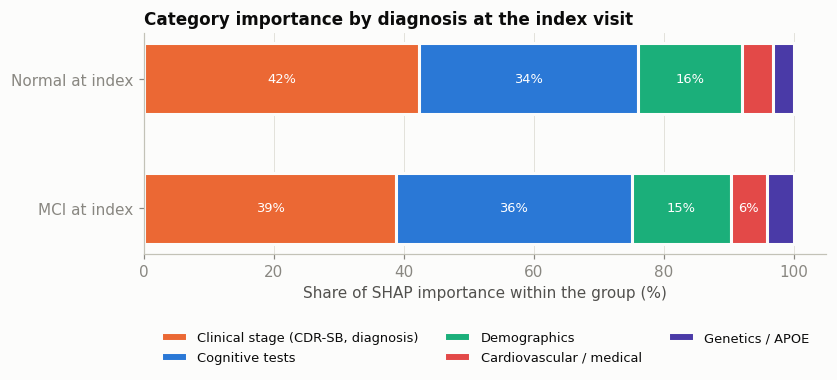

,Normal at index,MCI at index
"Clinical stage (CDR-SB, diagnosis)",42.4,38.8
Cognitive tests,33.7,36.3
Demographics,16.0,15.2
Cardiovascular / medical,4.7,5.6
Genetics / APOE,3.2,4.1


In [3]:
by = pd.DataFrame(r["group_importance_by_index_dx"]); by = by / by.sum() * 100
by = by.reindex(gi.index)
fig, ax = plt.subplots(figsize=(8, 2.6))
left = np.zeros(2)
for g in by.index:
    ax.barh(by.columns, by.loc[g].values, left=left, color=GROUP_COLOR[g], label=g, edgecolor="#fcfcfb", linewidth=2, height=0.55)
    for i, (l, w) in enumerate(zip(left, by.loc[g].values)):
        if w > 5: ax.text(l + w / 2, i, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=8.5)
    left += by.loc[g].values
ax.invert_yaxis(); ax.set_xlabel("Share of SHAP importance within the group (%)"); ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.3), fontsize=8.5); ax.set_title("Category importance by diagnosis at the index visit")
nu.savefig(fig, "07_shap_groups_by_dx"); plt.show()
by.round(1)

The picture is almost identical in the two groups. Cardiovascular features are not more important for people who are still cognitively normal, at least over a 3-year horizon and with late-life measurements.

## 2. Which individual features?

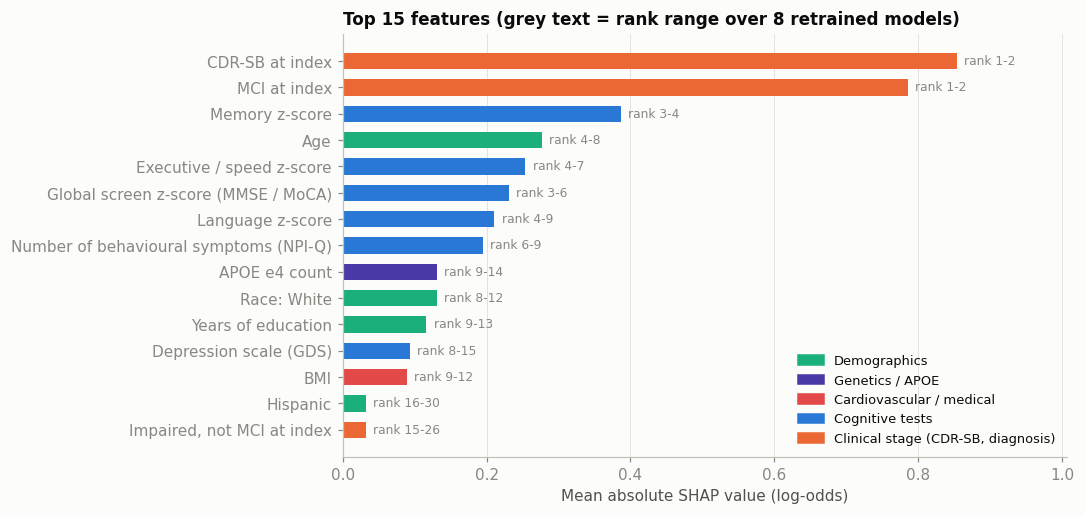

In [4]:
imp = pd.Series(r["feature_importance"]).head(15)
rr = r["stability"]["rank_range_top15"]
fig, ax = plt.subplots(figsize=(8.5, 5))
ypos = np.arange(len(imp))[::-1]
ax.barh(ypos, imp.values, color=[GROUP_COLOR[GROUP_OF[f]] for f in imp.index], height=0.62)
for yv, f in zip(ypos, imp.index):
    lo, hi = rr[f]; ax.text(imp[f] + 0.01, yv, f"rank {lo}" if lo == hi else f"rank {lo}-{hi}", va="center", fontsize=8, color=nu.MUTED)
ax.set_yticks(ypos, [LABEL.get(f, f) for f in imp.index]); ax.set_xlabel("Mean absolute SHAP value (log-odds)"); ax.grid(axis="y", visible=False)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLOR.values()]
ax.legend(handles, GROUP_COLOR.keys(), loc="lower right", fontsize=8.5); ax.set_title("Top 15 features (grey text = rank range over 8 retrained models)")
ax.set_xlim(0, imp.max() * 1.18); nu.savefig(fig, "07_shap_features"); plt.show()

### 2.1 How stable is the ranking?

The model was retrained eight times, each time on a bootstrap re-sample of the training participants, and the importance ranking recomputed.

In [5]:
st = r["stability"]
print(f"Rank correlation with the main model's ranking: {min(st['spearman_with_main_model']):.2f} to {max(st['spearman_with_main_model']):.2f}")
print(f"Features shared between each refit's top 10 and the main model's top 10: {min(st['top10_overlap_with_main_model'])} to {max(st['top10_overlap_with_main_model'])} of 10")
pd.DataFrame(rr, index=["Best rank", "Worst rank"]).T.rename(index=LABEL)

Rank correlation with the main model's ranking: 0.90 to 0.96
Features shared between each refit's top 10 and the main model's top 10: 8 to 10 of 10


,Best rank,Worst rank
CDR-SB at index,1,2
MCI at index,1,2
Memory z-score,3,4
Age,4,8
Executive / speed z-score,4,7
Global screen z-score (MMSE / MoCA),3,6
Language z-score,4,9
Number of behavioural symptoms (NPI-Q),6,9
APOE e4 count,9,14
Race: White,8,12


* The top two features (CDR-SB and MCI status) hold their places in every refit, and the main model's top 10 reappears almost unchanged (8 to 10 of 10).
* In the middle of the list the order is not fixed. Age ranges from 4th to 8th, language from 4th to 9th, APOE from 9th to 14th. These are the correlated cognitive scores and their neighbours trading places.

**So the defensible statements are at category level** ("current cognitive state dominates; age next; cardiovascular and APOE small"). A sentence such as "language was the fifth most important feature" should not appear in the report, because a different random seed would give a different answer.

## 3. In which direction?

For each leading feature, test participants are grouped by the feature's value, and the average SHAP contribution of each group is plotted. Above zero means that level pushes the predicted risk up.

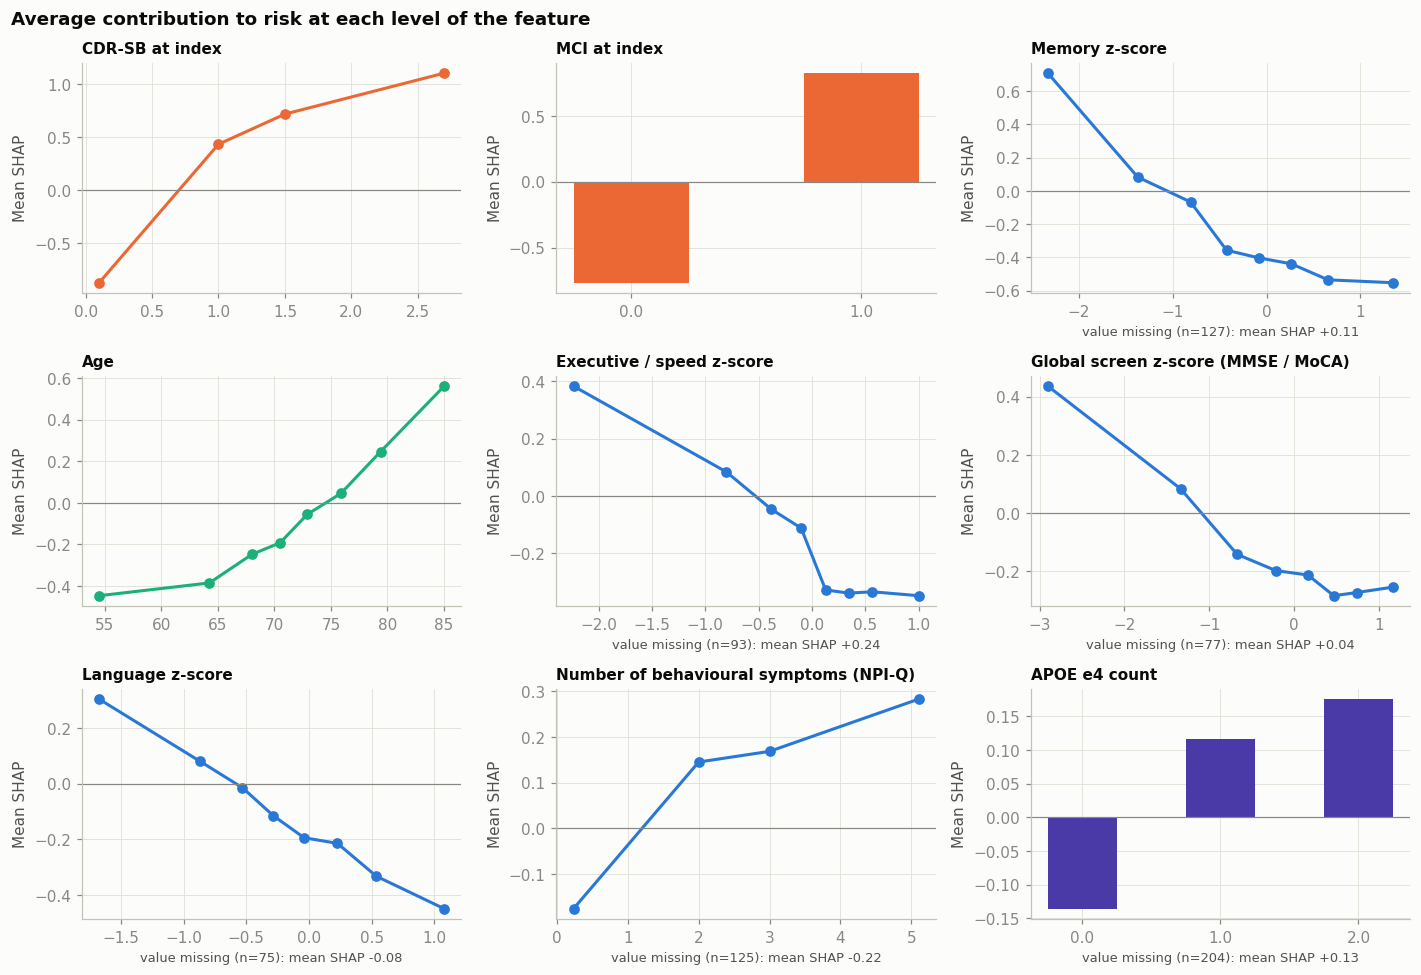

In [6]:
dep = r["dependence"]
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
for ax, (f, d) in zip(axes.ravel(), dep.items()):
    c = GROUP_COLOR[GROUP_OF[f]]
    if len(d["value"]) <= 3:
        ax.bar([str(round(v, 1)) for v in d["value"]], d["mean_shap"], color=c, width=0.5)
    else:
        ax.plot(d["value"], d["mean_shap"], marker="o", color=c)
    ax.axhline(0, color=nu.MUTED, lw=0.8); ax.set_title(LABEL.get(f, f), fontsize=10); ax.set_ylabel("Mean SHAP")
    if d["missing_n"] >= 20:
        ax.set_xlabel(f"value missing (n={d['missing_n']}): mean SHAP {d['missing_mean_shap']:+.2f}", fontsize=8.5)
fig.suptitle("Average contribution to risk at each level of the feature", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); nu.savefig(fig, "07_shap_dependence"); plt.show()

The directions are the ones a clinician would expect, which is the main sanity check on the model:

* higher CDR-SB, MCI at the index visit, older age and more behavioural symptoms push risk **up**;
* better memory, executive, language and global scores push risk **down**, with most of the effect concentrated at the low end (once a score is around average or better, improving it further changes little);
* each APOE e4 copy pushes risk up. People who were **not genotyped** get a contribution similar to carrying one e4 copy. That is the model using "missing" as information, which is why it was kept as its own flag instead of being filled in. It also means the explanation shown to a user must say "APOE unknown", not imply a genotype.

One item to follow up in validation: **race** appears in the top 15. In this cohort race is entangled with which centre recruited the person and how they were referred, so this is more likely a recruitment effect than biology. Performance and calibration must be checked separately by race, and the team should decide whether race stays in the model.

## 4. What to say, and what not to say

**Supported by the evidence here**

* The model's predictions are driven mainly by current cognitive state (clinical stage and test scores), then age.
* Cardiovascular and medical features, as measured in late life in NACC, contribute a small share (5 to 10%) and APOE less (1 to 5%).
* Category-level importance is stable across retraining; the effects point in clinically sensible directions.

**Not supported, and to be avoided in the report**

* Any causal wording ("hypertension causes...", "lowering X would reduce risk"). SHAP describes the model.
* Fine-grained rankings of individual cognitive features.
* "Cardiovascular health does not matter for dementia." The finding is narrower: *given* a person's current cognition, late-life cardiovascular records add little to a 3-year prediction in this cohort. Mid-life exposure, which the literature points to, is not observed in NACC.

**Used later.** The same per-person SHAP values feed the clinician interface ("top factors behind this estimate"), grouped by category for the reasons above.